In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load dataset
df=pd.read_csv("../data/Master_data/Feature_Engineering_dataset.csv")
print(df.head)

In [4]:
df.shape

(482257, 74)

In [5]:
df.columns

Index(['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc',
       'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount',
       'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs',
       'totalUnits', 'units', 'distCode', 'distName', 'officeCode',
       'officeName', 'longitude', 'latitude', 'fpsStatus', 'fpsType',
       'dateTime', 'day_name', 'week', 'quarter', 'is_weekend', 'day_of_year',
       'month_start', 'month_end', 'days_in_month', 'utilization_ratio',
       'units_per_card', 'amount_per_transaction', 'amount_per_card',
       'rice_afsc_per_trans', 'rice_fsc_per_trans', 'rice_aap_per_trans',
       'wheat_per_trans', 'rice_to_wheat_ratio', 'sugar_intensity',
       'wheat_intensity', 'rice_share', 'commodity_activity',
       'other_shop_ratio', 'portability_hub_score', 'portability_intensity',
       'high_non_local_flag', 'trans_per_card_FRAUD_DETECTION',
       'units_per_trans_FRAUD_DETECTION', 'fraud_risk_flag', 'post_onorc',
       '

In [6]:
print(df.dtypes)

print(df.dtypes.to_string())



shopNo                  int64
month                   int64
year                    int64
noOfRcs               float64
noOfTrans             float64
                       ...   
low_activity_shop       int64
high_revenue_shop       int64
availability_score      int64
active_fps              int64
missing_geo_flag        int64
Length: 74, dtype: object
shopNo                               int64
month                                int64
year                                 int64
noOfRcs                            float64
noOfTrans                          float64
riceAfsc                           float64
riceFsc                            float64
riceAap                            float64
wheat                              float64
sugar                              float64
totalAmount                        float64
otherShopTransCnt                    int64
riceAap_available                    int64
wheat_available                      int64
totalRcs                           float64

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_cols.tolist())

Numerical Columns:
['shopNo', 'month', 'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap', 'wheat', 'sugar', 'totalAmount', 'otherShopTransCnt', 'riceAap_available', 'wheat_available', 'totalRcs', 'totalUnits', 'units', 'distCode', 'officeCode', 'longitude', 'latitude', 'week', 'quarter', 'is_weekend', 'day_of_year', 'month_start', 'month_end', 'days_in_month', 'utilization_ratio', 'units_per_card', 'amount_per_transaction', 'amount_per_card', 'rice_afsc_per_trans', 'rice_fsc_per_trans', 'rice_aap_per_trans', 'wheat_per_trans', 'rice_to_wheat_ratio', 'sugar_intensity', 'wheat_intensity', 'rice_share', 'commodity_activity', 'other_shop_ratio', 'portability_hub_score', 'portability_intensity', 'high_non_local_flag', 'trans_per_card_FRAUD_DETECTION', 'units_per_trans_FRAUD_DETECTION', 'fraud_risk_flag', 'post_onorc', 'urban_proxy', 'distribution_change', 'transaction_volatility', 'amount_volatility', 'commodity_volatility', 'amount_growth', 'commodity_growth', 'activity_dens

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['distName', 'officeName', 'fpsStatus', 'fpsType', 'dateTime', 'day_name']


In [9]:
print(df.isnull().sum())

shopNo                0
month                 0
year                  0
noOfRcs               0
noOfTrans             0
                     ..
low_activity_shop     0
high_revenue_shop     0
availability_score    0
active_fps            0
missing_geo_flag      0
Length: 74, dtype: int64


In [10]:
#TREND ANALYSIS
#Analyze growth of portability transactions (otherShopTransCnt) from 2023 to 2025
#Year-wise Trend Analysis
trend_year = df.groupby('year')['otherShopTransCnt'].sum().reset_index()

print(trend_year)

   year  otherShopTransCnt
0  2023           26229782
1  2024           25079645
2  2025           11871066


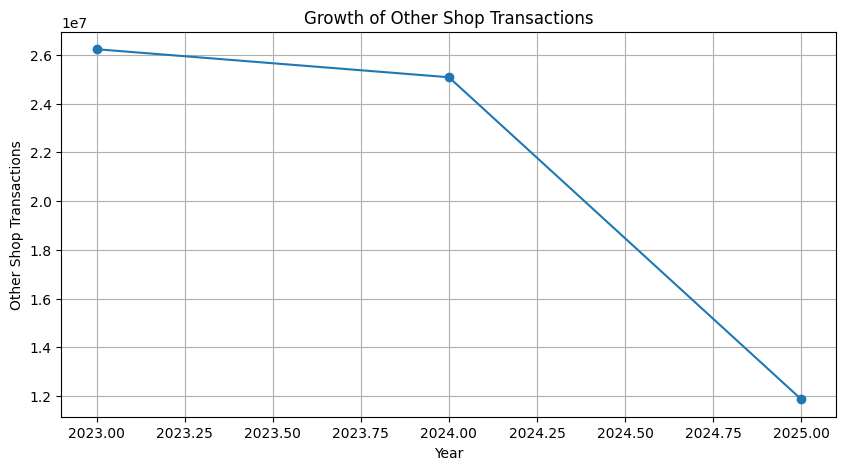

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    trend_year['year'],
    trend_year['otherShopTransCnt'],
    marker='o'
)

plt.title('Growth of Other Shop Transactions')
plt.xlabel('Year')
plt.ylabel('Other Shop Transactions')

plt.grid(True)
plt.show()

#Project/EDA insigh
#The number of other shop transactions showed a slight decline from 2023 to 2024, followed by a sharp drop in 2025. 
# This may indicate reduced portability usage or incomplete data availability for 2025.

In [14]:
#Months-wise Trend Analysis
monthly_trend = df.groupby(['year', 'month'])['otherShopTransCnt'].sum().reset_index()

print(monthly_trend)

    year  month  otherShopTransCnt
0   2023      1            2136928
1   2023      2            2122868
2   2023      3            2152233
3   2023      4            2181711
4   2023      5            2148435
5   2023      6            2174362
6   2023      7            2200680
7   2023      8            2223284
8   2023      9            2231040
9   2023     10            2178428
10  2023     11            2219042
11  2023     12            2260771
12  2024      1            2268846
13  2024      2            2248452
14  2024      3            2252329
15  2024      4            2253478
16  2024      5            2259190
17  2024      6            2277065
18  2024      7            2295966
19  2024      8            2280342
20  2024      9            2304575
21  2024     11            2302736
22  2024     12            2336666
23  2025      1            2354001
24  2025      2            2337426
25  2025      3            2353236
26  2025      4            2416853
27  2025      5     

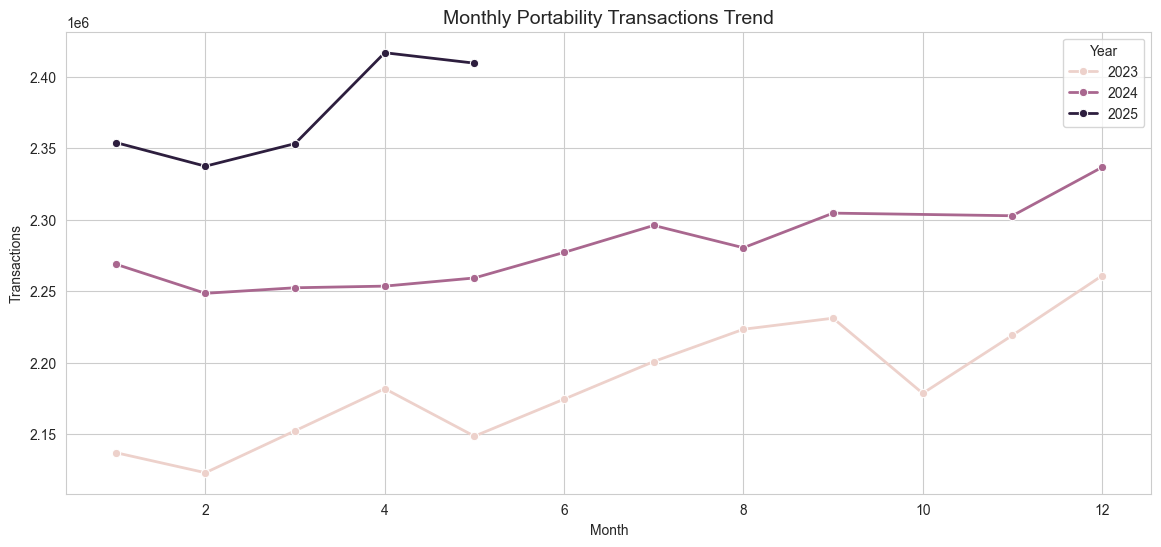

In [15]:
plt.figure(figsize=(14,6))
sns.set_style("whitegrid")

sns.lineplot(
    data=monthly_trend,
    x='month',
    y='otherShopTransCnt',
    hue='year',
    marker='o',
    linewidth=2
)

plt.title('Monthly Portability Transactions Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Transactions')

plt.legend(title='Year')
plt.show()

#Portability transactions showed a gradual increase during later months of the year, especially in 2024.
# The trend suggests possible seasonal spikes in ration portability during festival 
# or harvest periods. The 2025 trend appears incomplete due to limited monthly data availability.

In [16]:
#CORRELATION STUDY
#Analyze relationship between:
#totalRcs (Entitlement)
#noOfTrans (Execution)

corr_cols = [
    'totalRcs',
    'noOfTrans',
    'totalUnits',
    'otherShopTransCnt'
]

corr_matrix = df[corr_cols].corr()

print(corr_matrix)

                   totalRcs  noOfTrans  totalUnits  otherShopTransCnt
totalRcs           1.000000   0.893862    0.976184           0.599041
noOfTrans          0.893862   1.000000    0.887485           0.718922
totalUnits         0.976184   0.887485    1.000000           0.621232
otherShopTransCnt  0.599041   0.718922    0.621232           1.000000


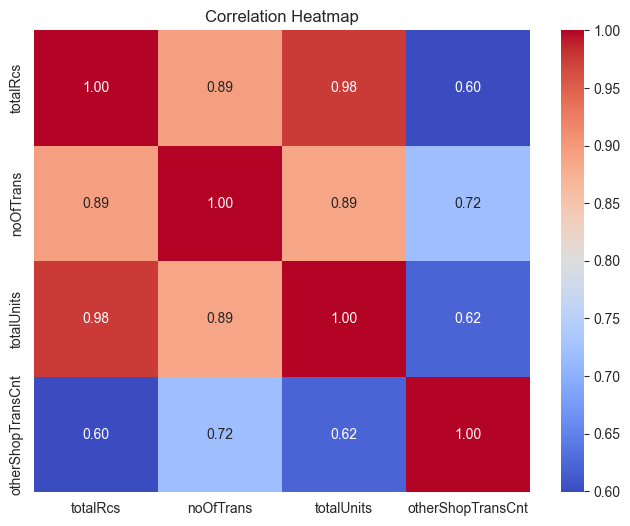

In [17]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

#1. totalRcs ↔ noOfTrans = 0.89 (Strong Positive Correlatio)
#2. totalRcs ↔ totalUnits = 0.98(Very Strong Correlation)
#3. noOfTrans ↔ totalUnits = 0.89(Strong Positive Correlation)
#4. otherShopTransCnt ↔ noOfTrans = 0.72(Moderately Strong Correlation)
#5. otherShopTransCnt ↔ totalRcs = 0.60(Moderate Correlation)

#The correlation analysis shows a strong positive relationship between entitlement (totalRcs), transactions (noOfTrans), and 
# total units distributed (totalUnits). Portability transactions (otherShopTransCnt) show a moderate correlation, indicating that other external factors
#  may influence portability usage.

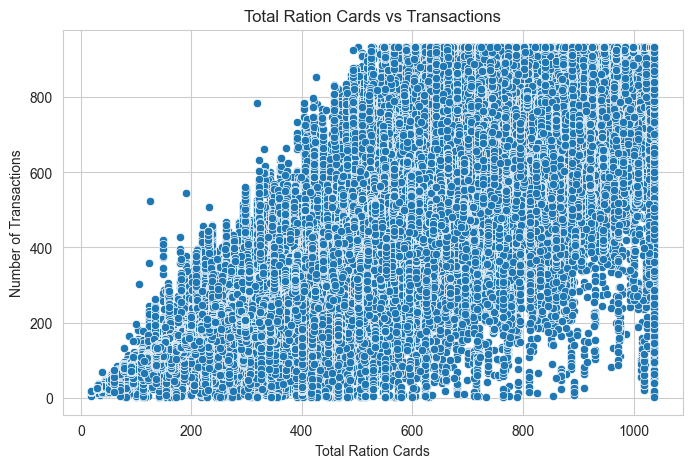

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='totalRcs',
    y='noOfTrans'
)

plt.title('Total Ration Cards vs Transactions')
plt.xlabel('Total Ration Cards')
plt.ylabel('Number of Transactions')
plt.show()

#“The scatter plot shows a positive relationship between total ration cards and transactions. 
# However, significant variability exists for shops with similar card counts, 
# indicating heterogeneous behavior. Some outliers with unusually high or low transactions 
# relative to ration cards may indicate suspicious or anomalous activity useful for fraud detection.”

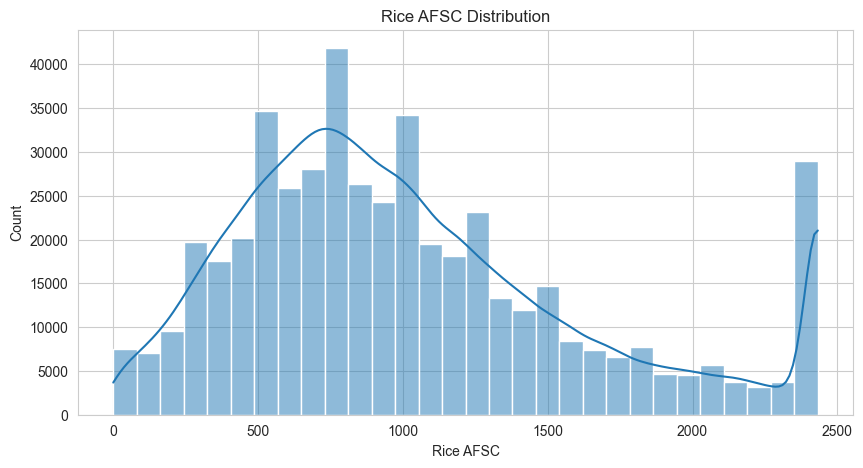

In [19]:
#DISTRIBUTION ANALYSIS
#Check distribution of:
#Rice
#Wheat Across districts
#Rice Distribution Histogram
plt.figure(figsize=(10,5))

sns.histplot(df['riceAfsc'], bins=30, kde=True)

plt.title('Rice AFSC Distribution')
plt.xlabel('Rice AFSC')
plt.show()


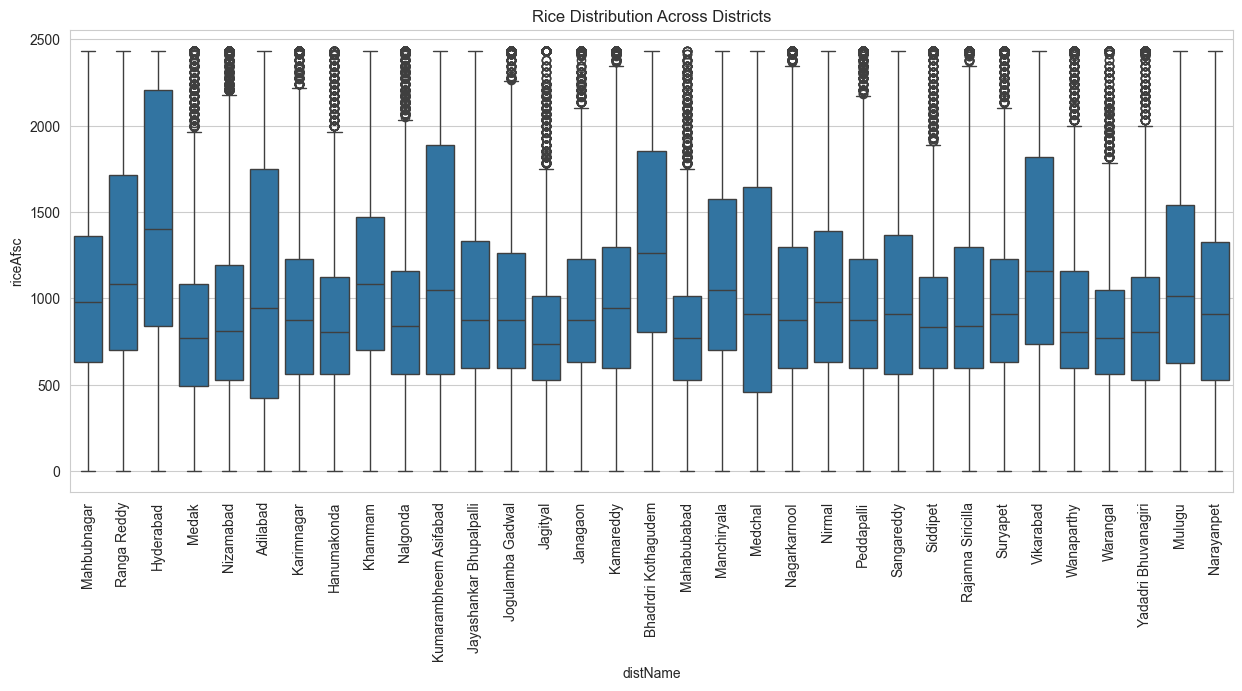

In [20]:
#Rice Boxplot by District
plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x='distName',
    y='riceAfsc'
)

plt.xticks(rotation=90)
plt.title('Rice Distribution Across Districts')
plt.show()

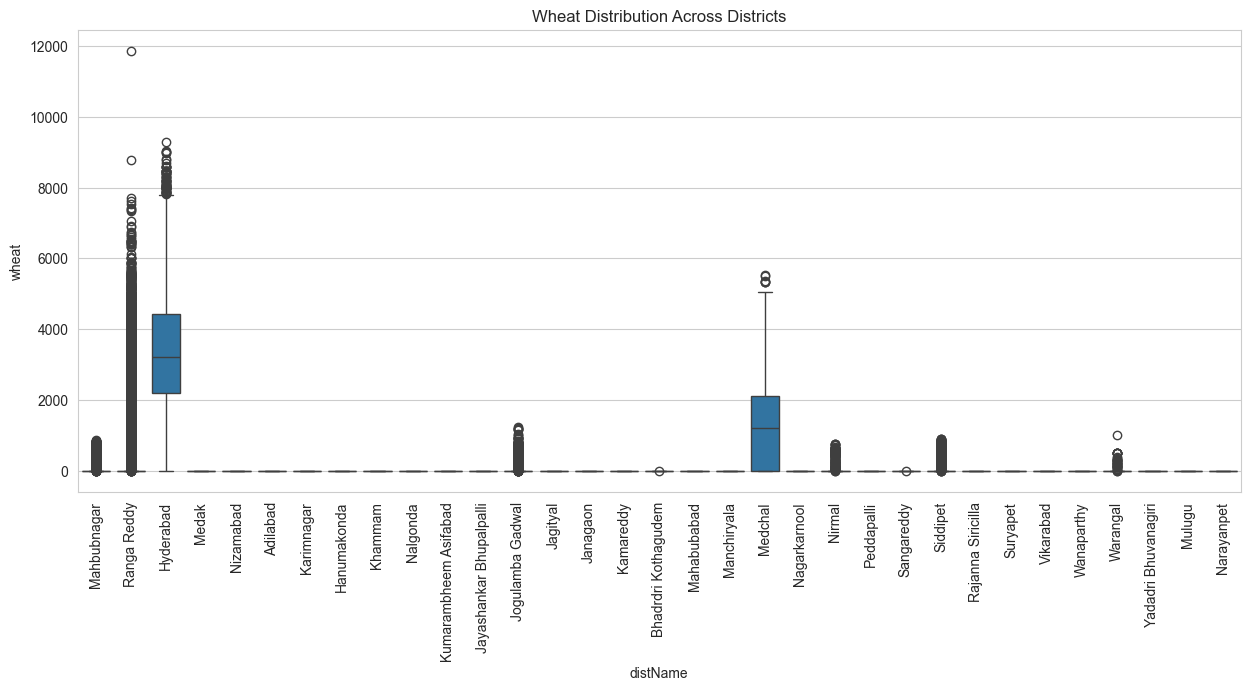

In [21]:
#Wheat Boxplot by District

plt.figure(figsize=(15,6))

sns.boxplot(
    data=df,
    x='distName',
    y='wheat'
)

plt.xticks(rotation=90)
plt.title('Wheat Distribution Across Districts')
plt.show()

In [22]:
#SEASONALITY ANALYSIS
#Monthly Transaction Analysis
seasonality = df.groupby('month')['noOfTrans'].sum().reset_index()
print(seasonality)

    month   noOfTrans
0       1  22168423.0
1       2  21965660.5
2       3  22090237.5
3       4  22375906.5
4       5  22186144.0
5       6  14682786.0
6       7  14715913.0
7       8  14679520.0
8       9  14790145.5
9      10   7379633.5
10     11  14808037.0
11     12  14890430.5


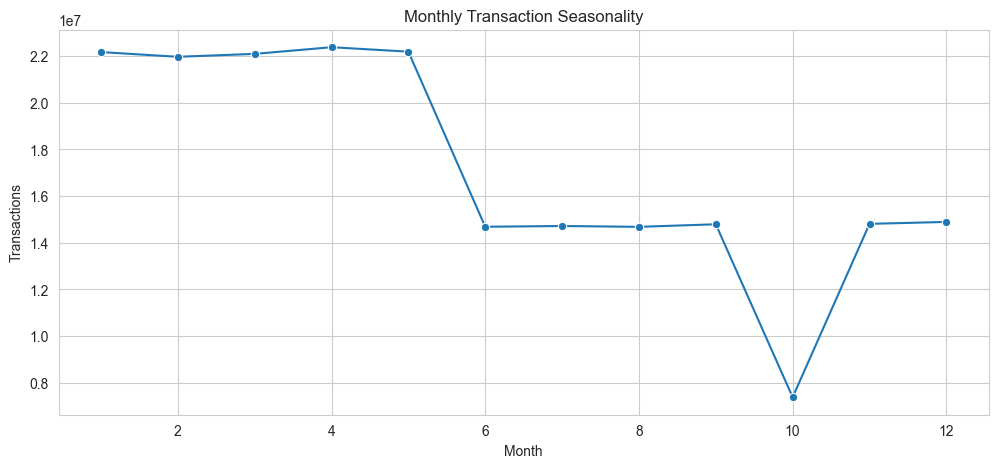

In [23]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=seasonality,
    x='month',
    y='noOfTrans',
    marker='o'
)

plt.title('Monthly Transaction Seasonality')
plt.xlabel('Month')
plt.ylabel('Transactions')
plt.show()

In [24]:
#Quarter-wise Analysis
quarter_data = df.groupby('quarter')['noOfTrans'].sum().reset_index()

print(quarter_data)

   quarter    noOfTrans
0        3  206732837.0


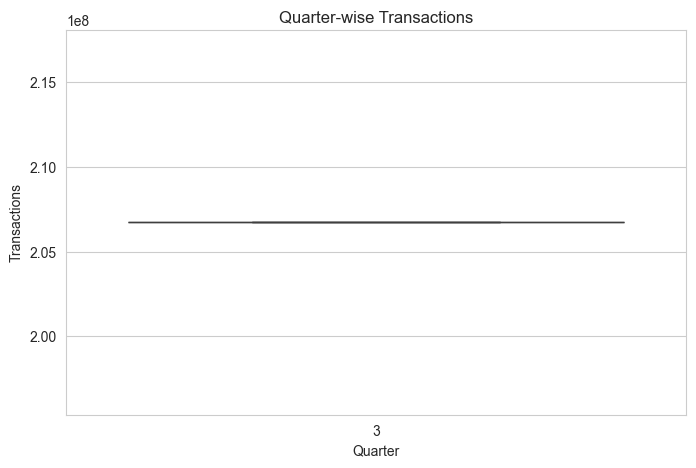

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=quarter_data,
    x='quarter',
    y='noOfTrans'
)

plt.title('Quarter-wise Transactions')
plt.xlabel('Quarter')
plt.ylabel('Transactions')
plt.show()

In [26]:
#OPTIONAL FEATURE ENGINEERING
#Utilization Ratio
# Transactions per ration card

df['utilization_ratio'] = df['noOfTrans'] / df['totalRcs']

print(df[['utilization_ratio']].head())


   utilization_ratio
0           0.698551
1           0.750725
2           0.710145
3           0.721739
4           0.750725


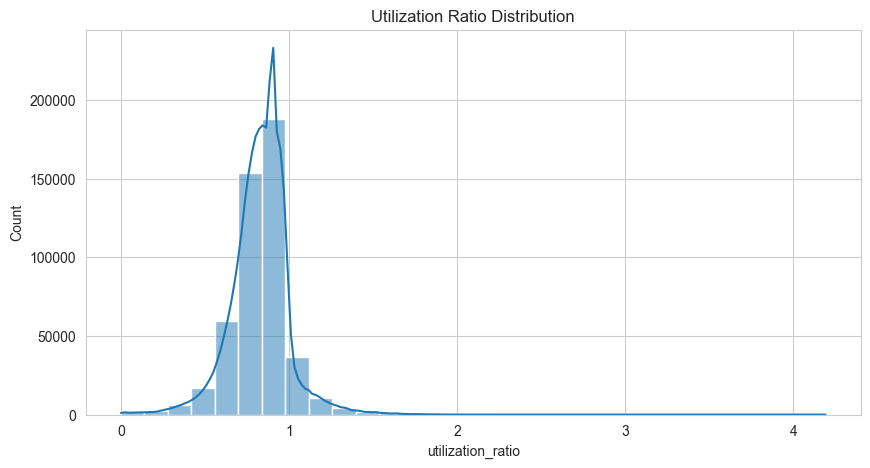

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(df['utilization_ratio'], bins=30, kde=True)

plt.title('Utilization Ratio Distribution')
plt.show()

In [28]:
#FINAL IMPORTANT EDA FEATURES
important_features = [
    'year',
    'month',
    'otherShopTransCnt',
    'totalRcs',
    'noOfTrans',
    'riceAfsc',
    'riceFsc',
    'riceAap',
    'wheat',
    'distName',
    'quarter'
]


In [29]:
#LOCATION-BASED EDA
#Analyze district-wise and location-wise transaction patterns.
#District-wise Transactions
location_trend = df.groupby('distName')['noOfTrans'].sum().reset_index()

print(location_trend.head())

              distName   noOfTrans
0             Adilabad   4794109.0
1  Bhadrdri Kothagudem   6237108.0
2          Hanumakonda   5234018.0
3            Hyderabad  14114117.5
4             Jagityal   7656543.0


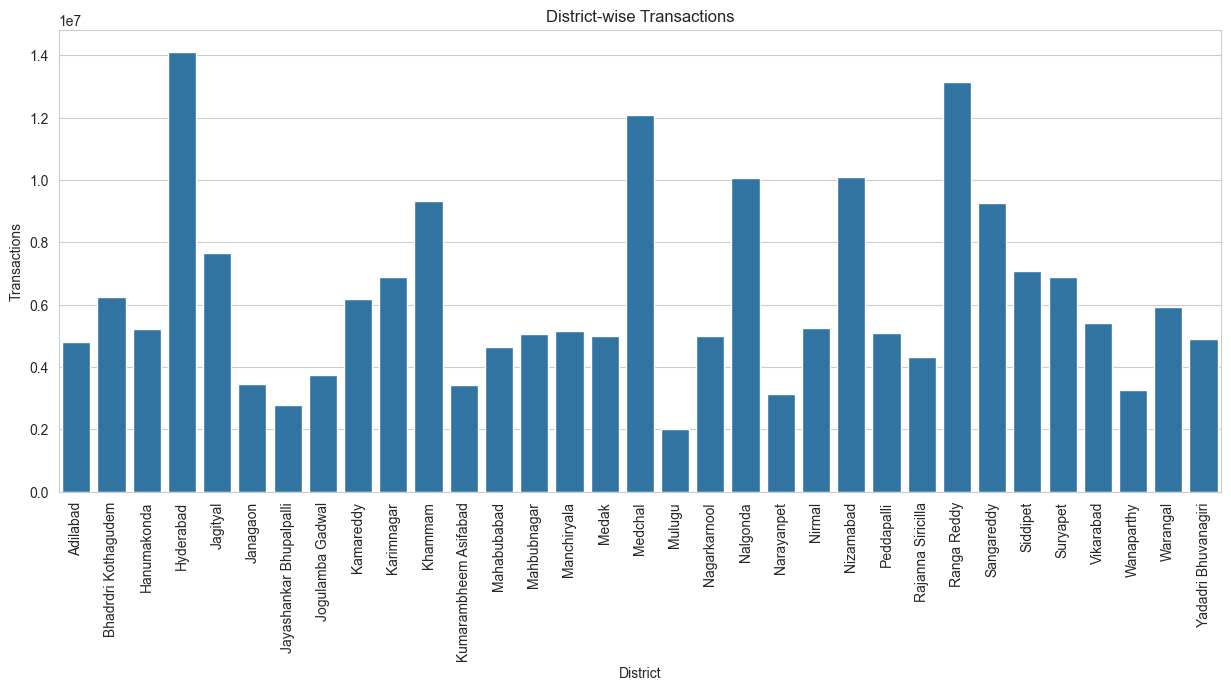

In [30]:
#Plot District-wise Transactions
plt.figure(figsize=(15,6))

sns.barplot(
    data=location_trend,
    x='distName',
    y='noOfTrans'
)

plt.xticks(rotation=90)
plt.title('District-wise Transactions')
plt.xlabel('District')
plt.ylabel('Transactions')
plt.show()

In [31]:
#District-wise Portability Transactions
portability = df.groupby('distName')['otherShopTransCnt'].sum().reset_index()

print(portability.head())

              distName  otherShopTransCnt
0             Adilabad            1113656
1  Bhadrdri Kothagudem            1420133
2          Hanumakonda            1882091
3            Hyderabad            7898802
4             Jagityal            2100187


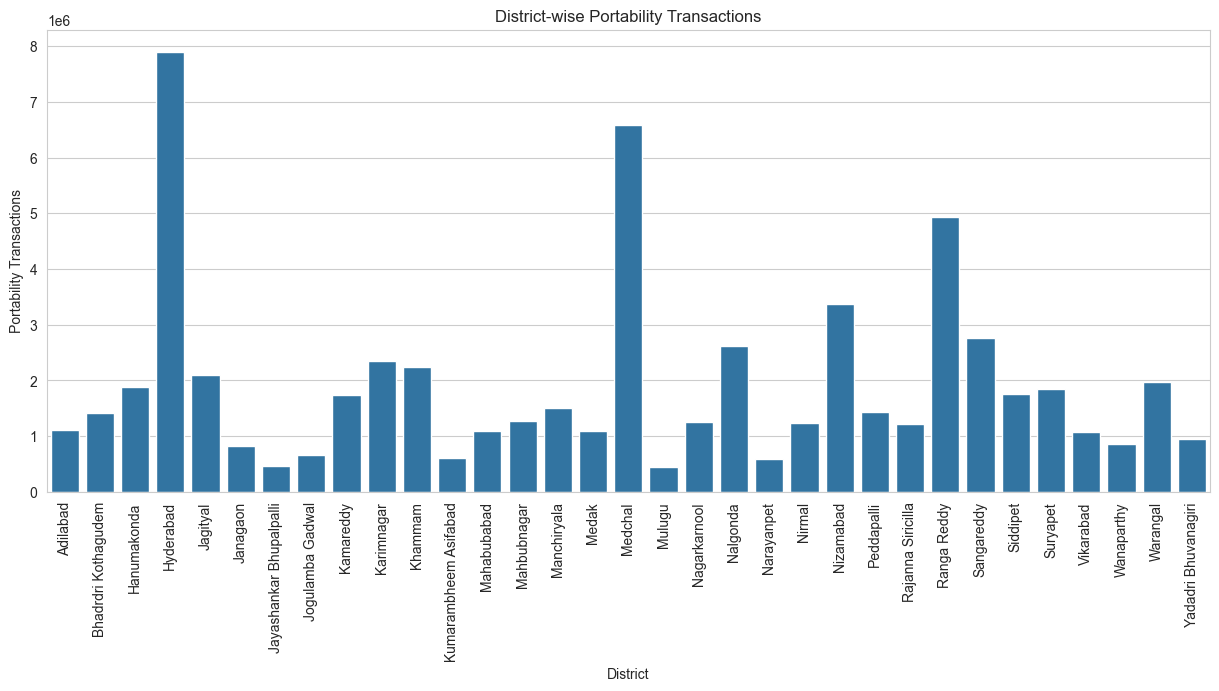

In [32]:
#Plot Portability by District
plt.figure(figsize=(15,6))

sns.barplot(
    data=portability,
    x='distName',
    y='otherShopTransCnt'
)

plt.xticks(rotation=90)
plt.title('District-wise Portability Transactions')
plt.xlabel('District')
plt.ylabel('Portability Transactions')
plt.show()

In [33]:
#Top 10 Districts by Transactions
top10 = df.groupby('distName')['noOfTrans'] \
          .sum() \
          .sort_values(ascending=False) \
          .head(10)

print(top10)

distName
Hyderabad      14114117.5
Ranga Reddy    13138674.0
Medchal        12082487.5
Nizamabad      10092745.0
Nalgonda       10068575.5
Khammam         9318006.0
Sangareddy      9272636.5
Jagityal        7656543.0
Siddipet        7080835.5
Karimnagar      6892369.0
Name: noOfTrans, dtype: float64


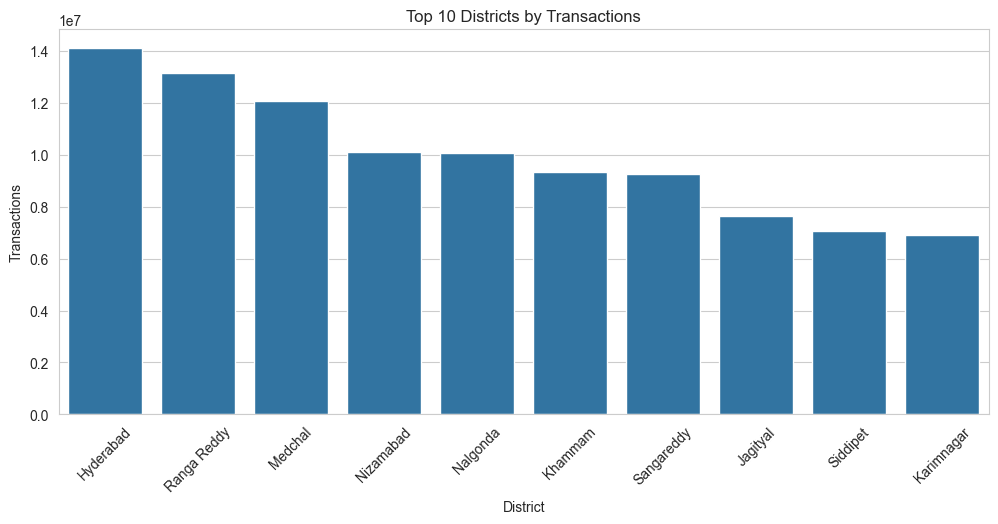

In [34]:
#Plot Top 10 Districts
plt.figure(figsize=(12,5))

sns.barplot(
    x=top10.index,
    y=top10.values
)

plt.xticks(rotation=45)
plt.title('Top 10 Districts by Transactions')
plt.xlabel('District')
plt.ylabel('Transactions')
plt.show()

In [35]:
#Latitude & Longitude Analysis
print(df[['latitude', 'longitude']].head())

    latitude  longitude
0  16.755785  77.789107
1  16.755785  77.789107
2  16.755785  77.789107
3  16.755785  77.789107
4  16.755785  77.789107


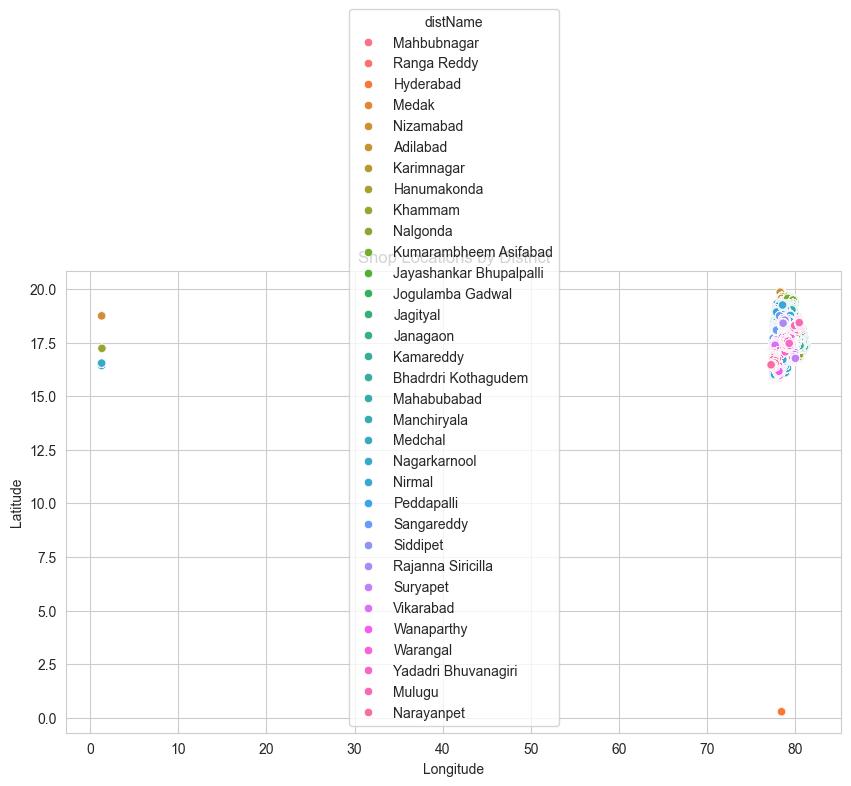

In [36]:
#Scatter Plot for Shop Locations
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='distName'
)

plt.title('Shop Locations by District')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [37]:
df[(df['longitude'] == 0) | (df['latitude'] == 0)]

,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,...,district_load,seasonal_demand,peak_month_flag,festival_quarter,high_performance_shop,low_activity_shop,high_revenue_shop,availability_score,active_fps,missing_geo_flag


In [38]:
df = df[
    (df['longitude'] > 0) &
    (df['latitude'] > 0)
]

In [39]:
df[['longitude', 'latitude']] = (
    df[['longitude', 'latitude']]
    .replace(0, np.nan)
)

In [40]:
print((df['longitude'] == 0).sum())
print((df['latitude'] == 0).sum())

0
0


In [41]:
df[['longitude', 'latitude']].isnull().sum()

longitude    0
latitude     0
dtype: int64

In [42]:
df[df['longitude'].isnull() | df['latitude'].isnull()].head()

,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,...,district_load,seasonal_demand,peak_month_flag,festival_quarter,high_performance_shop,low_activity_shop,high_revenue_shop,availability_score,active_fps,missing_geo_flag


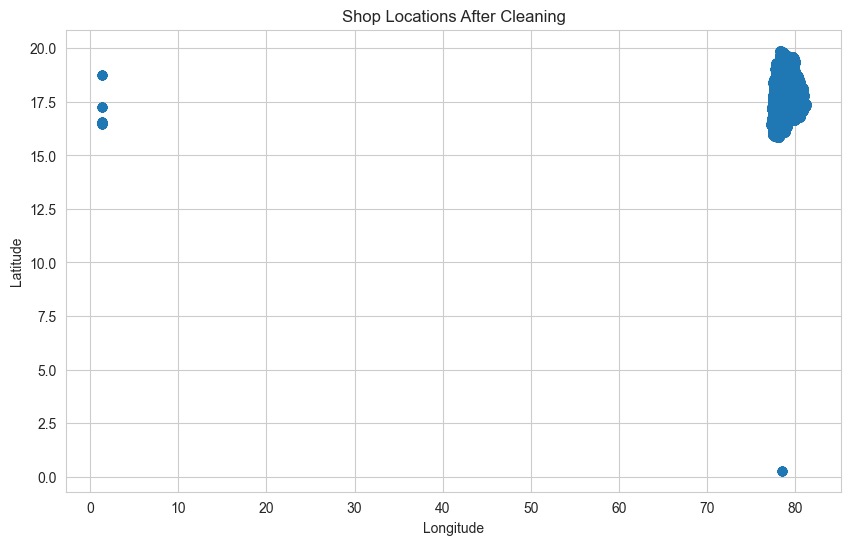

In [43]:
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=['longitude', 'latitude'])

plt.figure(figsize=(10,6))

plt.scatter(
    plot_df['longitude'],
    plot_df['latitude'],
    alpha=0.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Shop Locations After Cleaning')
plt.show()

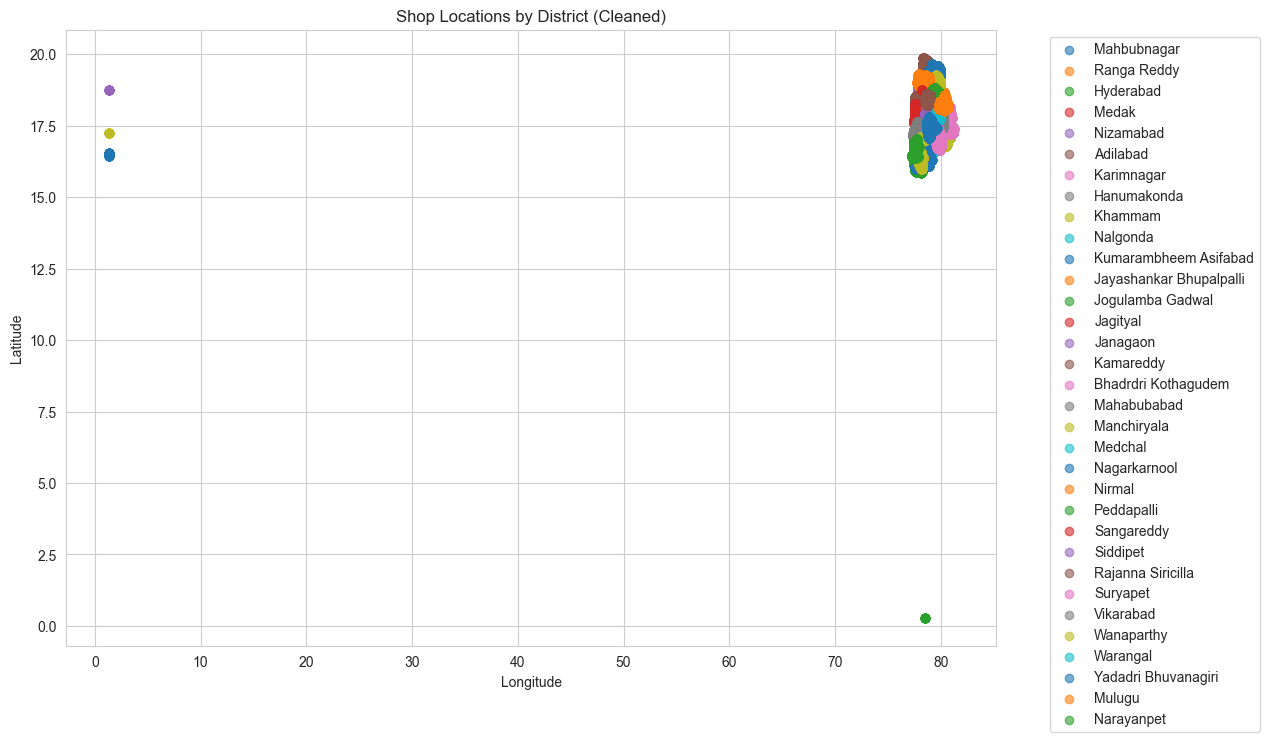

In [44]:
#District-wise dekhna ho to
import matplotlib.pyplot as plt

plot_df = df.dropna(subset=['longitude', 'latitude'])

plt.figure(figsize=(12,8))

for district in plot_df['distName'].unique():
    temp = plot_df[plot_df['distName'] == district]
    
    plt.scatter(
        temp['longitude'],
        temp['latitude'],
        label=district,
        alpha=0.6
    )

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Shop Locations by District (Cleaned)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

In [45]:
df[['longitude','latitude']].describe()

,longitude,latitude
count,482257.000000,482257.000000
mean,78.853228,17.739871
std,1.429099,0.821183
min,1.300000,0.283333
25%,78.269220,17.189153
50%,78.732635,17.629694
75%,79.494689,18.332146
max,81.263470,19.880502


In [46]:
df[
    (df['longitude'] < 70) |
    (df['latitude'] < 10)
][['shopNo', 'distName', 'longitude', 'latitude']]

,shopNo,distName,longitude,latitude
42939,1672250,Hyderabad,78.469668,0.283333
42940,1672250,Hyderabad,78.469668,0.283333
42941,1672250,Hyderabad,78.469668,0.283333
42942,1672250,Hyderabad,78.469668,0.283333
42943,1672250,Hyderabad,78.469668,0.283333
...,...,...,...,...
319799,3419027,Nagarkarnool,1.300000,16.549730
319800,3419027,Nagarkarnool,1.300000,16.549730
319801,3419027,Nagarkarnool,1.300000,16.549730
319802,3419027,Nagarkarnool,1.300000,16.549730


In [47]:
df = df[
    (df['longitude'].between(75, 82)) &
    (df['latitude'].between(15, 21))
]

In [48]:
df[['longitude', 'latitude']].describe()

,longitude,latitude
count,482117.000000,482117.000000
mean,78.871265,17.740999
std,0.803528,0.810299
min,77.283265,15.862739
25%,78.269540,17.189176
50%,78.732635,17.629694
75%,79.494819,18.332146
max,81.263470,19.880502


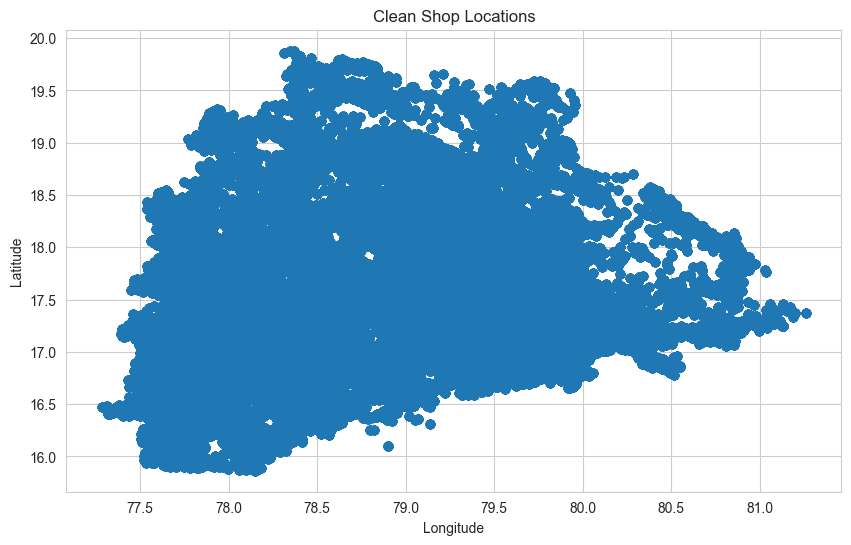

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    alpha=0.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clean Shop Locations')
plt.show()

#“After cleaning invalid geospatial coordinates, the shop locations formed a realistic regional cluster.
#  This confirmed improved data quality and enabled meaningful geographic analysis for 
# anomaly detection and location-based fraud patterns.”

In [50]:
#FRAUD ANALYSIS EDA
#Detect suspicious shops, abnormal transactions, outliers,
#  and possible fraud patterns.

#High Transaction Shops
high_trans = df.groupby('shopNo')['noOfTrans'] \
               .sum() \
               .sort_values(ascending=False) \
               .head(10)

print(high_trans)

shopNo
1678850    26138.0
1678890    26138.0
1678898    26138.0
1679935    26138.0
1679929    26138.0
1673309    26138.0
3384070    26138.0
3384066    26138.0
3384042    26138.0
1532039    26138.0
Name: noOfTrans, dtype: float64


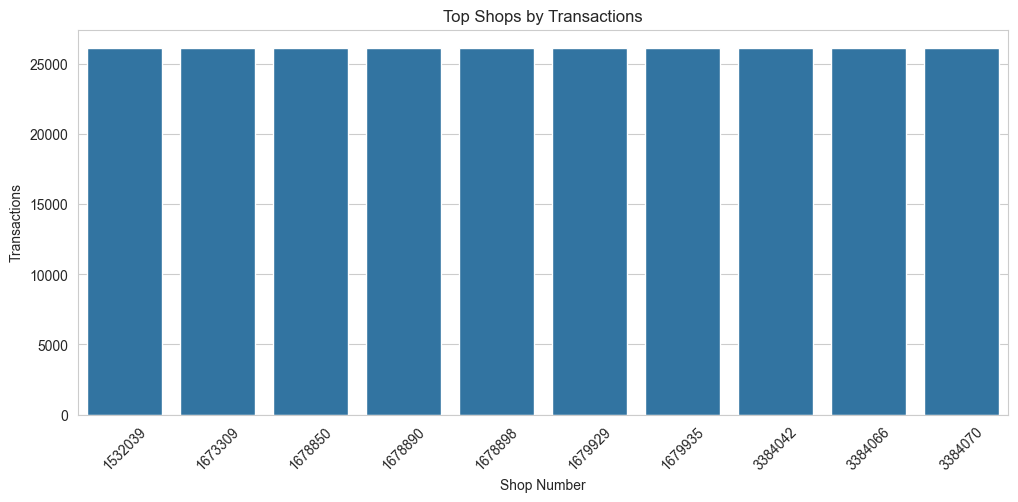

In [51]:
#Plot High Transaction Shops
plt.figure(figsize=(12,5))

sns.barplot(
    x=high_trans.index,
    y=high_trans.values
)

plt.xticks(rotation=45)
plt.title('Top Shops by Transactions')
plt.xlabel('Shop Number')
plt.ylabel('Transactions')
plt.show()

In [52]:
#Utilization Ratio
#Transactions / Total Ration Cards
df['utilization_ratio'] = df['noOfTrans'] / df['totalRcs']

print(df[['shopNo', 'utilization_ratio']])

         shopNo  utilization_ratio
0       1407001           0.698551
1       1407001           0.750725
2       1407001           0.710145
3       1407001           0.721739
4       1407001           0.750725
...         ...                ...
482252  4612012           0.693603
482253  4612012           0.693603
482254  4612012           0.595870
482255  4612012           0.720000
482256  4612012           0.701538

[482117 rows x 2 columns]


In [53]:
#: Detect Abnormal Utilization
suspicious_ratio = df[df['utilization_ratio'] > 2]

print(suspicious_ratio[['shopNo', 'utilization_ratio']].head())

        shopNo  utilization_ratio
33798  1585676           2.460815
33799  1585676           2.063348
33854  1585678           2.885714
34459  1585761           2.853403
34581  1585770           2.887097


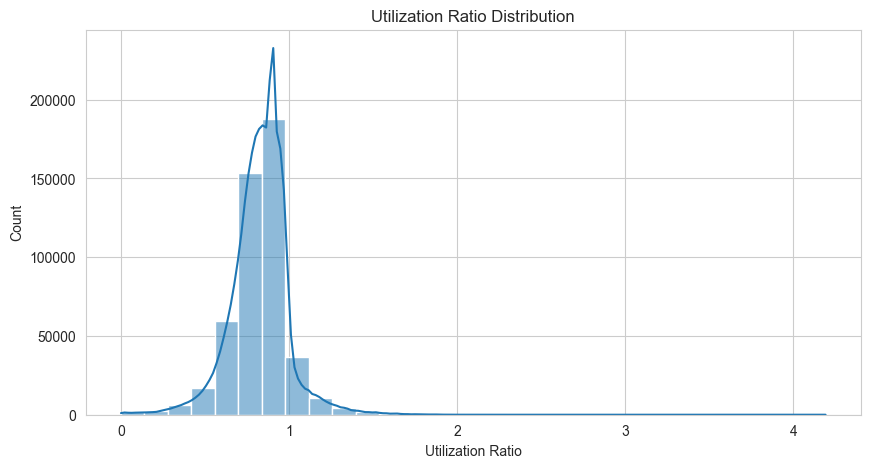

In [54]:
#Plot Utilization Ratio
plt.figure(figsize=(10,5))

sns.histplot(df['utilization_ratio'], bins=30, kde=True)

plt.title('Utilization Ratio Distribution')
plt.xlabel('Utilization Ratio')
plt.show()

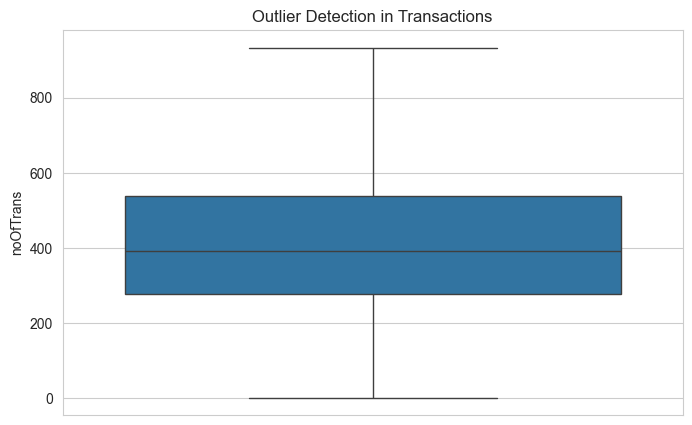

In [55]:
#Boxplot for Outlier Detection
plt.figure(figsize=(8,5))

sns.boxplot(y=df['noOfTrans'])

plt.title('Outlier Detection in Transactions')
plt.show()

In [56]:
#Detect Transaction Outliers Using IQR
Q1 = df['noOfTrans'].quantile(0.25)
Q3 = df['noOfTrans'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['noOfTrans'] < lower_bound) |
    (df['noOfTrans'] > upper_bound)
]

print(outliers[['shopNo', 'noOfTrans']].head())

Empty DataFrame
Columns: [shopNo, noOfTrans]
Index: []


In [57]:
#Portability Fraud Analysis
portability_fraud = df[
    df['otherShopTransCnt'] > df['noOfTrans']
]

print(portability_fraud[['shopNo', 'otherShopTransCnt', 'noOfTrans']].head())



Empty DataFrame
Columns: [shopNo, otherShopTransCnt, noOfTrans]
Index: []


In [59]:
#Commodity Mismatch Analysis
df['rice_wheat_ratio'] = df['riceAfsc'] / (df['wheat'] + 1)

print(df[['shopNo', 'rice_wheat_ratio']].head())

    shopNo  rice_wheat_ratio
0  1407001             805.0
1  1407001             910.0
2  1407001             840.0
3  1407001             840.0
4  1407001             840.0


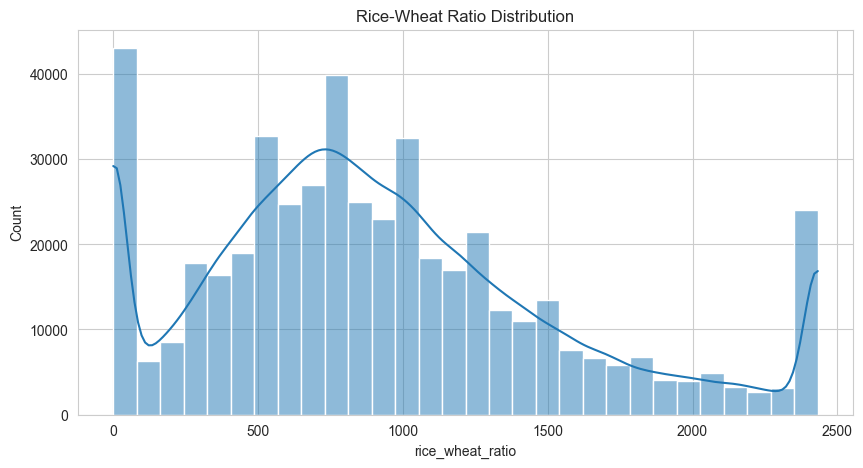

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(df['rice_wheat_ratio'], bins=30, kde=True)

plt.title('Rice-Wheat Ratio Distribution')
plt.show()

In [61]:
#Monthly Fraud Pattern Analysis
monthly_fraud = df.groupby('month')['noOfTrans'].mean().reset_index()

print(monthly_fraud)

    month   noOfTrans
0       1  428.988898
1       2  425.311200
2       3  427.449467
3       4  432.843948
4       5  429.294110
5       6  426.434526
6       7  427.274065
7       8  426.121428
8       9  429.253542
9      10  428.480977
10     11  429.649396
11     12  432.086899


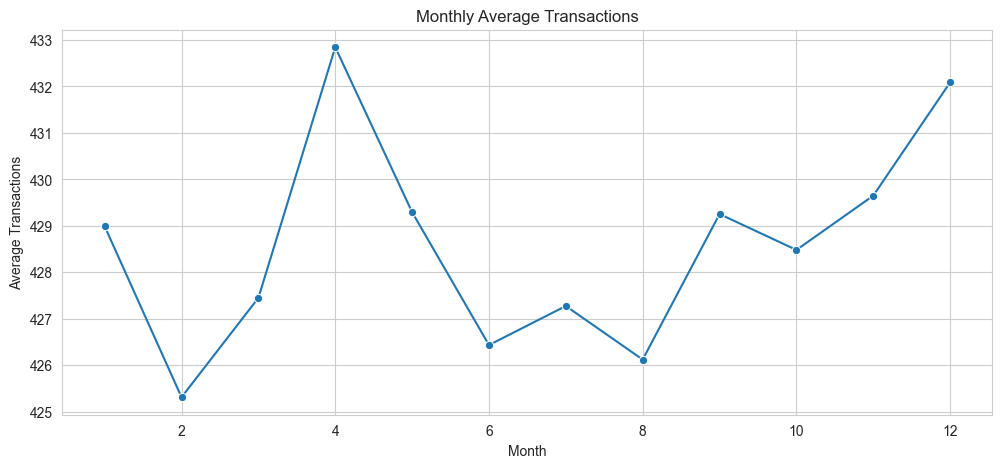

In [62]:
#Plot Monthly Fraud Trend
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_fraud,
    x='month',
    y='noOfTrans',
    marker='o'
)

plt.title('Monthly Average Transactions')
plt.xlabel('Month')
plt.ylabel('Average Transactions')
plt.show()

In [63]:
print(df['urban_proxy'].value_counts())


urban_proxy
0    241602
1    240515
Name: count, dtype: int64


In [64]:
#Urban vs Rural Transaction Comparison
urban_rural_trans = (
    df.groupby('urban_proxy')['noOfTrans']
    .mean()
    .reset_index()
)

# Rename values
urban_rural_trans['urban_proxy'] = (
    urban_rural_trans['urban_proxy']
    .map({1: 'Urban', 0: 'Rural'})
)

print(urban_rural_trans)

  urban_proxy   noOfTrans
0       Rural  394.767134
1       Urban  462.657404


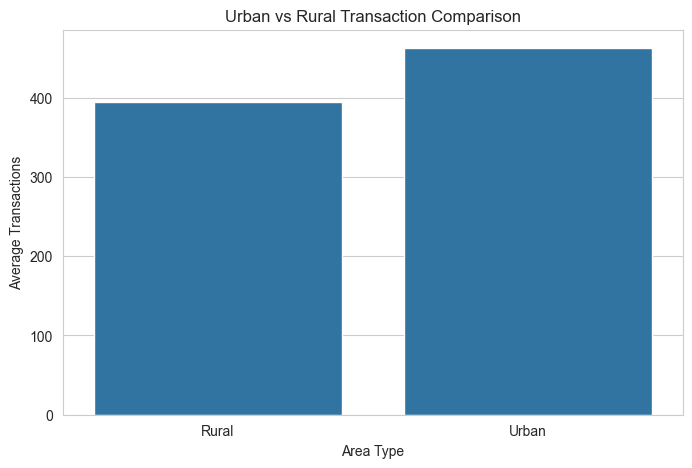

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=urban_rural_trans,
    x='urban_proxy',
    y='noOfTrans'
)

plt.title('Urban vs Rural Transaction Comparison')
plt.xlabel('Area Type')
plt.ylabel('Average Transactions')

plt.show()

In [66]:
#Portability Comparison
urban_portability = (
    df.groupby('urban_proxy')['otherShopTransCnt']
    .mean()
    .reset_index()
)

urban_portability['urban_proxy'] = (
    urban_portability['urban_proxy']
    .map({1:'Urban', 0:'Rural'})
)

print(urban_portability)

  urban_proxy  otherShopTransCnt
0       Rural         100.270445
1       Urban         161.811966


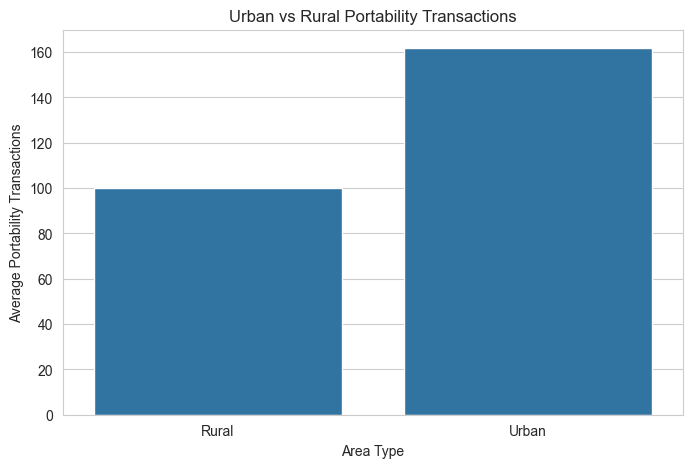

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=urban_portability,
    x='urban_proxy',
    y='otherShopTransCnt'
)

plt.title('Urban vs Rural Portability Transactions')
plt.xlabel('Area Type')
plt.ylabel('Average Portability Transactions')

plt.show()

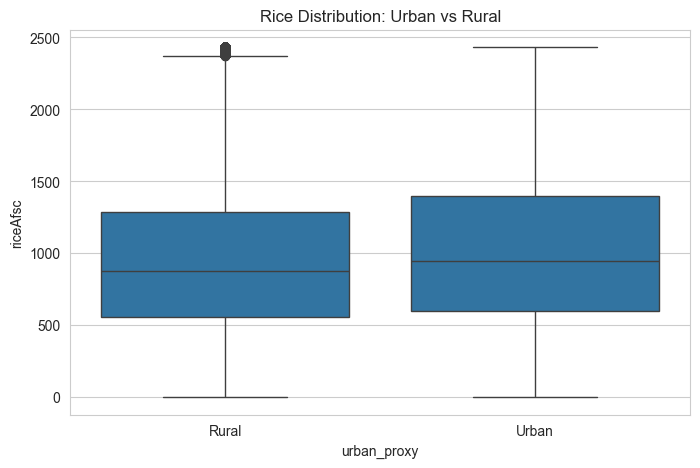

In [68]:
#Commodity Distribution (Urban vs Rural)
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='urban_proxy',
    y='riceAfsc'
)

plt.xticks([0,1], ['Rural', 'Urban'])

plt.title('Rice Distribution: Urban vs Rural')

plt.show()


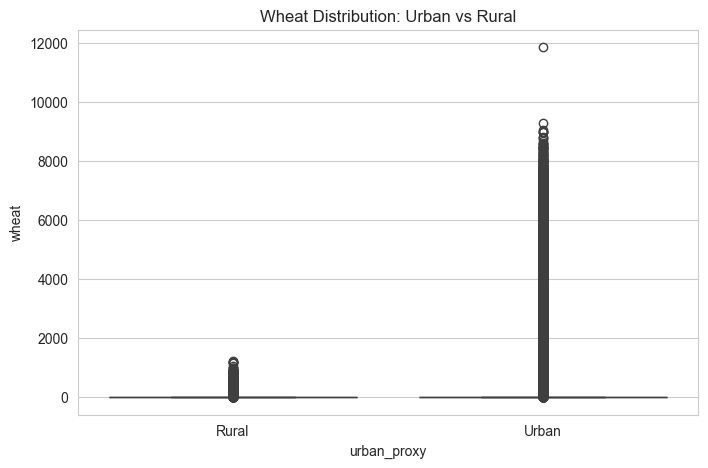

In [69]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='urban_proxy',
    y='wheat'
)

plt.xticks([0,1], ['Rural', 'Urban'])

plt.title('Wheat Distribution: Urban vs Rural')

plt.show()

In [70]:
#Fraud Risk Comparison
fraud_analysis = (
    df.groupby('urban_proxy')['fraud_risk_flag']
    .mean()
    .reset_index()
)

fraud_analysis['urban_proxy'] = (
    fraud_analysis['urban_proxy']
    .map({1:'Urban', 0:'Rural'})
)

print(fraud_analysis)

  urban_proxy  fraud_risk_flag
0       Rural         0.004917
1       Urban         0.015113


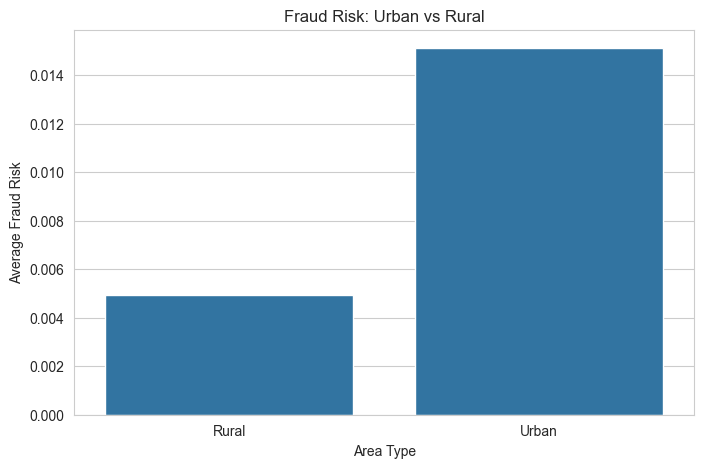

In [71]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=fraud_analysis,
    x='urban_proxy',
    y='fraud_risk_flag'
)

plt.title('Fraud Risk: Urban vs Rural')
plt.xlabel('Area Type')
plt.ylabel('Average Fraud Risk')

plt.show()

#Urban regions showed higher transaction and portability activity compared to rural areas, indicating 
# the influence of population density and mobility patterns.

In [72]:
df.to_csv("../data/Master_data/EDA_ANALYSIS_data.csv", index=False)

In [73]:
df.shape

(482117, 75)